In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('train.csv')

display(df.head())

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


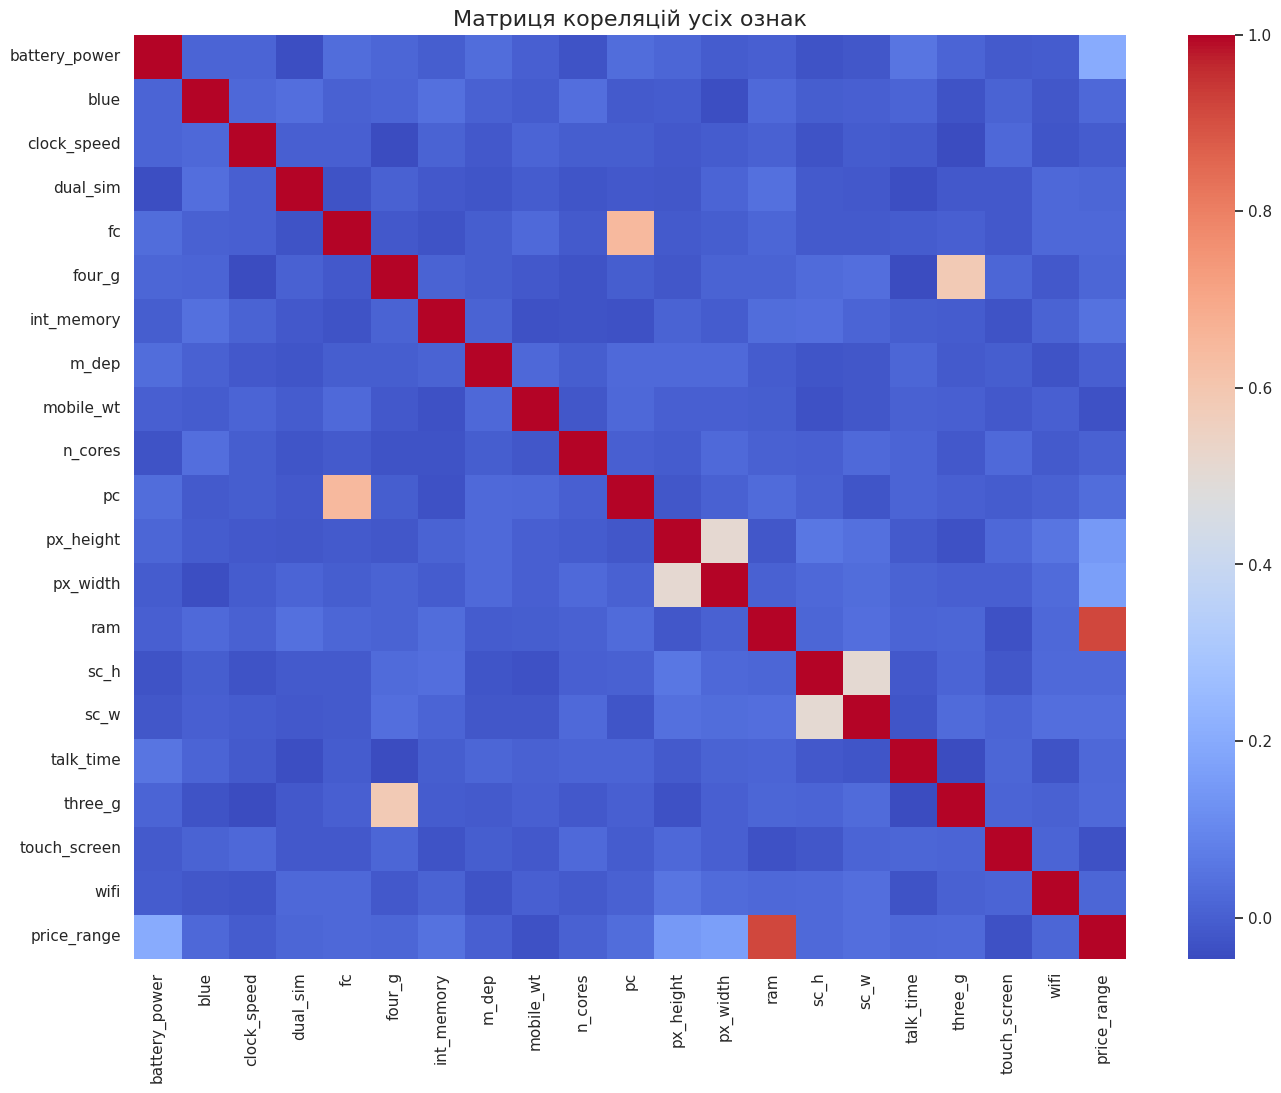

Кореляція ознак з ціновою категорією (price_range):
price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


In [8]:
plt.figure(figsize=(16, 12))

correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Матриця кореляцій усіх ознак", fontsize=16)
plt.show()

print("Кореляція ознак з ціновою категорією (price_range):")
print(correlation_matrix['price_range'].sort_values(ascending=False))

/tmp/ipykernel_13539/2909043030.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='price_range', y='ram', palette='viridis', ax=axes[0, 1])
/tmp/ipykernel_13539/2909043030.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='price_range', y='battery_power', palette='viridis', ax=axes[1, 1])


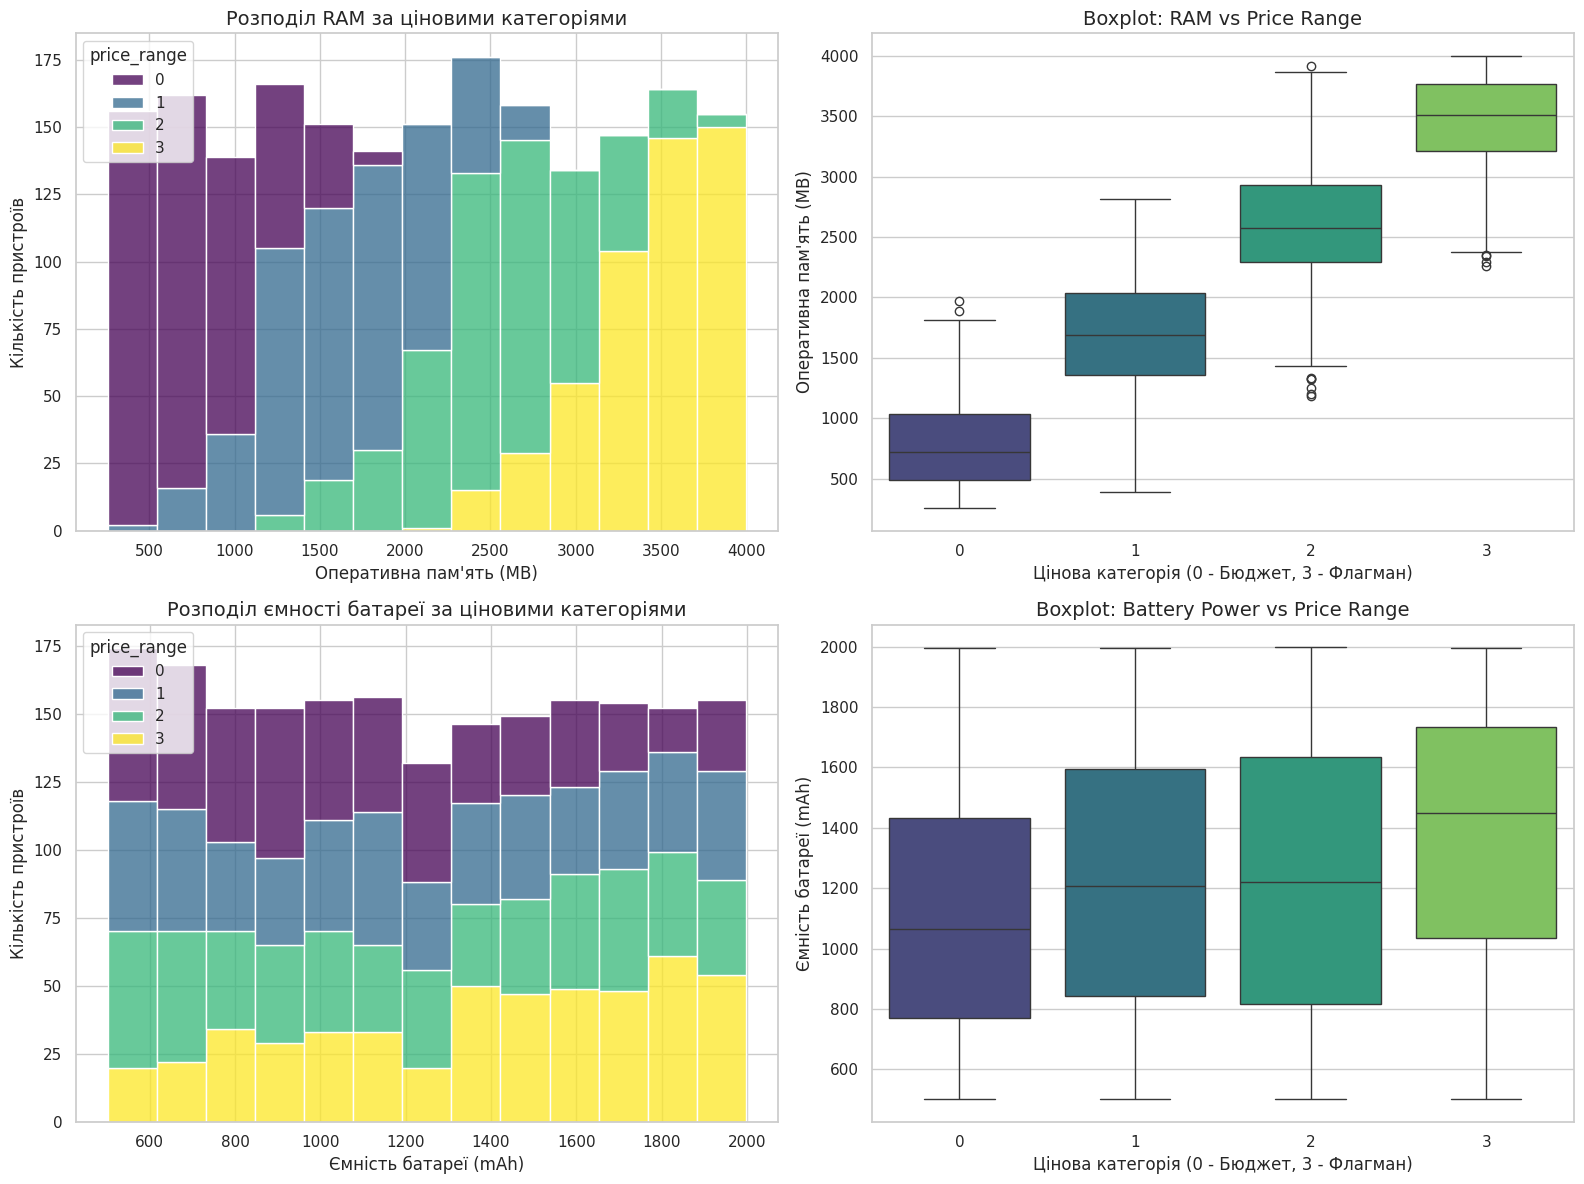

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(data=df, x='ram', hue='price_range', palette='viridis', multiple='stack', ax=axes[0, 0])
axes[0, 0].set_title("Розподіл RAM за ціновими категоріями", fontsize=14)
axes[0, 0].set_xlabel("Оперативна пам'ять (MB)")
axes[0, 0].set_ylabel("Кількість пристроїв")

sns.boxplot(data=df, x='price_range', y='ram', palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title("Boxplot: RAM vs Price Range", fontsize=14)
axes[0, 1].set_xlabel("Цінова категорія (0 - Бюджет, 3 - Флагман)")
axes[0, 1].set_ylabel("Оперативна пам'ять (MB)")

sns.histplot(data=df, x='battery_power', hue='price_range', palette='viridis', multiple='stack', ax=axes[1, 0])
axes[1, 0].set_title("Розподіл ємності батареї за ціновими категоріями", fontsize=14)
axes[1, 0].set_xlabel("Ємність батареї (mAh)")
axes[1, 0].set_ylabel("Кількість пристроїв")

sns.boxplot(data=df, x='price_range', y='battery_power', palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title("Boxplot: Battery Power vs Price Range", fontsize=14)
axes[1, 1].set_xlabel("Цінова категорія (0 - Бюджет, 3 - Флагман)")
axes[1, 1].set_ylabel("Ємність батареї (mAh)")

plt.tight_layout()
plt.show()

In [11]:
missing_values = df.isnull().sum()

print("Пропущені значення в кожній колонці:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("У датасеті немає пропущених значень.")
elif missing_values.sum() > 0:

    df = df.fillna(df.median())

    print(f"Залишилось пропусків: {df.isnull().sum().sum()}")

Пропущені значення в кожній колонці:
Series([], dtype: int64)
У датасеті немає пропущених значень.


In [12]:
from sklearn.model_selection import train_test_split

X = df.drop('price_range', axis=1)
y = df['price_range']

#80% на навчання, 20% на тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Розмір тренувальної вибірки: {X_train.shape[0]} телефонів")
print(f"Розмір тестової вибірки: {X_test.shape[0]} телефонів")

Розмір тренувальної вибірки: 1600 телефонів
Розмір тестової вибірки: 400 телефонів


In [13]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("Дані після масштабування:")
display(X_train_scaled_df.head())

Дані після масштабування:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1.389193,1.011314,-1.259189,0.986343,1.309253,-1.036932,1.584829,-0.704590,-1.250335,-1.551637,0.350239,-0.798849,-1.285642,-0.363024,-0.781290,-0.177627,-0.896645,-1.788708,-1.008789,-1.025320
1,0.078406,1.011314,-1.259189,-1.013846,1.770460,-1.036932,-0.003457,-1.396849,-0.768374,1.073159,0.844549,1.582302,1.637675,-1.547896,0.647082,1.875207,0.560944,-1.788708,-1.008789,0.975305
2,-1.024573,-0.988813,1.187471,0.986343,-0.074370,0.964384,1.365755,1.372187,-1.392089,1.510625,0.350239,-1.361502,-0.199305,1.698985,-0.067104,0.506651,-0.896645,0.559063,0.991288,0.975305
3,0.386692,-0.988813,-1.259189,0.986343,-0.535577,0.964384,0.106080,1.026057,-1.193634,-0.676705,-0.803150,0.832847,0.278589,1.649232,-0.781290,0.506651,-1.625440,0.559063,-1.008789,0.975305
4,-0.723138,-0.988813,0.698139,0.986343,0.156234,-1.036932,-0.386837,-0.358460,-0.711673,1.073159,0.679779,-0.985650,-0.392794,-1.234632,-0.543228,0.278558,-1.078844,-1.788708,0.991288,0.975305


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


log_reg = LogisticRegression(random_state=42, max_iter=1000)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

log_reg.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)
xgb_model.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_xgb = xgb_model.predict(X_test_scaled)

acc_log = accuracy_score(y_test, y_pred_log)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("Точність (Accuracy)")
print(f"Logistic Regression: {acc_log * 100:.2f}%")
print(f"Random Forest:       {acc_rf * 100:.2f}%")
print(f"XGBoost:             {acc_xgb * 100:.2f}%\n")

print("Детальний звіт для Logistic Regression")
print(classification_report(y_test, y_pred_log))

Починаємо навчання моделей...



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Точність (Accuracy)
Logistic Regression: 96.50%
Random Forest:       88.00%
XGBoost:             93.50%

Детальний звіт для Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



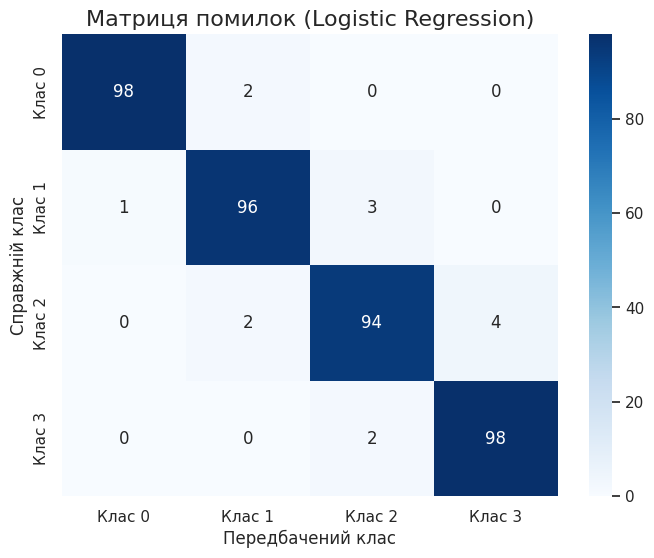

In [15]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Клас 0', 'Клас 1', 'Клас 2', 'Клас 3'],
            yticklabels=['Клас 0', 'Клас 1', 'Клас 2', 'Клас 3'])
plt.title('Матриця помилок (Logistic Regression)', fontsize=16)
plt.xlabel('Передбачений клас', fontsize=12)
plt.ylabel('Справжній клас', fontsize=12)
plt.show()

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log, average='weighted')
recall = recall_score(y_test, y_pred_log, average='weighted')
f1 = f1_score(y_test, y_pred_log, average='weighted')

print("=== Фінальна оцінка якості ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

=== Фінальна оцінка якості ===
Accuracy: 0.9650
Precision: 0.9650
Recall: 0.9650
F1-Score: 0.9650


In [18]:
import joblib

joblib.dump(log_reg, 'model.pkl')
print("✅ Модель успішно збережено у файл 'model.pkl'")

joblib.dump(scaler, 'scaler.pkl')
print("✅ Скейлер успішно збережено у файл 'scaler.pkl'")

✅ Модель успішно збережено у файл 'model.pkl'
✅ Скейлер успішно збережено у файл 'scaler.pkl'
